Healthcare Analytics — Doctor Visits
1. Project Objective

Problem Statement

Analyze patient characteristics, health conditions, insurance/access factors, and previous healthcare indicators to understand the factors associated with the number of doctor visits.

In [ ]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
# Load Dataset
df = pd.read_csv("/content/1776250375-P2-Healthcare Analytics for Doctor Visits.csv")

In [ ]:
# Understand The Dataset
print("Shape of dataset:", df.shape)

Shape of dataset: (5190, 13)


In [ ]:
df.head()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [ ]:
df.tail()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
5185,5186,0,female,0.22,0.55,0,0,0,no,no,no,no,no
5186,5187,0,male,0.27,1.30,0,0,1,no,no,no,no,no
5187,5188,0,female,0.37,0.25,1,0,1,no,no,yes,no,no
5188,5189,0,female,0.52,0.65,0,0,0,no,no,no,no,no
5189,5190,0,male,0.72,0.25,0,0,0,no,no,yes,no,no


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ KB


In [ ]:
print(df.columns)

Index(['Unnamed: 0', 'visits', 'gender', 'age', 'income', 'illness', 'reduced',
       'health', 'private', 'freepoor', 'freerepat', 'nchronic', 'lchronic'],
      dtype='object')


In [ ]:
df.describe()

,Unnamed: 0,visits,age,income,illness,reduced,health
count,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000
mean,2595.500000,0.301734,0.406385,0.583160,1.431985,0.861850,1.217534
std,1498.368279,0.798134,0.204782,0.368907,1.384152,2.887628,2.124266
min,1.000000,0.000000,0.190000,0.000000,0.000000,0.000000,0.000000
25%,1298.250000,0.000000,0.220000,0.250000,0.000000,0.000000,0.000000
50%,2595.500000,0.000000,0.320000,0.550000,1.000000,0.000000,0.000000
75%,3892.750000,0.000000,0.620000,0.900000,2.000000,0.000000,2.000000
max,5190.000000,9.000000,0.720000,1.500000,5.000000,14.000000,12.000000


In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,5190.0,NaN,NaN,NaN,2595.5,1498.368279,1.0,1298.25,2595.5,3892.75,5190.0
visits,5190.0,NaN,NaN,NaN,0.301734,0.798134,0.0,0.0,0.0,0.0,9.0
gender,5190,2,female,2702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,5190.0,NaN,NaN,NaN,0.406385,0.204782,0.19,0.22,0.32,0.62,0.72
income,5190.0,NaN,NaN,NaN,0.58316,0.368907,0.0,0.25,0.55,0.9,1.5
illness,5190.0,NaN,NaN,NaN,1.431985,1.384152,0.0,0.0,1.0,2.0,5.0
reduced,5190.0,NaN,NaN,NaN,0.86185,2.887628,0.0,0.0,0.0,0.0,14.0
health,5190.0,NaN,NaN,NaN,1.217534,2.124266,0.0,0.0,0.0,2.0,12.0
private,5190,2,no,2892,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freepoor,5190,2,no,4968,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Insight**

1.The dataset contains 5,190 patient records.

2.There are 13 columns.

3.Variables include doctor visits, gender, age, income, illness, health indicators, insurance/access variables and chronic-condition indicators.

4.The dataset contains both numerical and categorical variables.

In [ ]:
# Understand each columns
column_description = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str),
    "Unique_Values": df.nunique(),
    "Missing_Values": df.isnull().sum()
})

column_description

,Column,Data_Type,Unique_Values,Missing_Values
Unnamed: 0,Unnamed: 0,int64,5190,0
visits,visits,int64,10,0
gender,gender,object,2,0
age,age,float64,12,0
income,income,float64,14,0
illness,illness,int64,6,0
reduced,reduced,int64,15,0
health,health,int64,13,0
private,private,object,2,0
freepoor,freepoor,object,2,0


In [ ]:
# Check Missing Values
missing = df.isnull().sum()

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_percentage
})

missing_df

,Missing_Count,Missing_Percentage
Unnamed: 0,0,0.0
visits,0,0.0
gender,0,0.0
age,0,0.0
income,0,0.0
illness,0,0.0
reduced,0,0.0
health,0,0.0
private,0,0.0
freepoor,0,0.0


**There are no missing values in the dataset, so no missing-value imputation is required.**

In [ ]:
# Check Duplicates Records
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
# check Unique Values
for col in df.columns:
    print("\n", "="*50)
    print(col)
    print(df[col].unique())


Unnamed: 0
[   1    2    3 ... 5188 5189 5190]

visits
[1 2 3 4 8 5 7 6 9 0]

gender
['female' 'male']

age
[0.19 0.22 0.27 0.32 0.37 0.42 0.47 0.52 0.57 0.62 0.67 0.72]

income
[0.55 0.45 0.9  0.15 0.35 0.65 0.25 0.   0.06 1.1  0.75 0.01 1.3  1.5 ]

illness
[1 3 2 5 4 0]

reduced
[ 4  2  0  5  1 13  7  3 14  6  8  9 10 12 11]

health
[ 1  0  9  2  6  5  7 11  4 12  3 10  8]

private
['yes' 'no']

freepoor
['no' 'yes']

freerepat
['no' 'yes']

nchronic
['no' 'yes']

lchronic
['no' 'yes']


In [ ]:
# Identify Numerical and Categorial columns
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Numerical columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['Unnamed: 0', 'visits', 'age', 'income', 'illness', 'reduced', 'health']

Categorical columns:
['gender', 'private', 'freepoor', 'freerepat', 'nchronic', 'lchronic']


In [ ]:
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

In [ ]:
df.head()

,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


**Univariate Analysis**

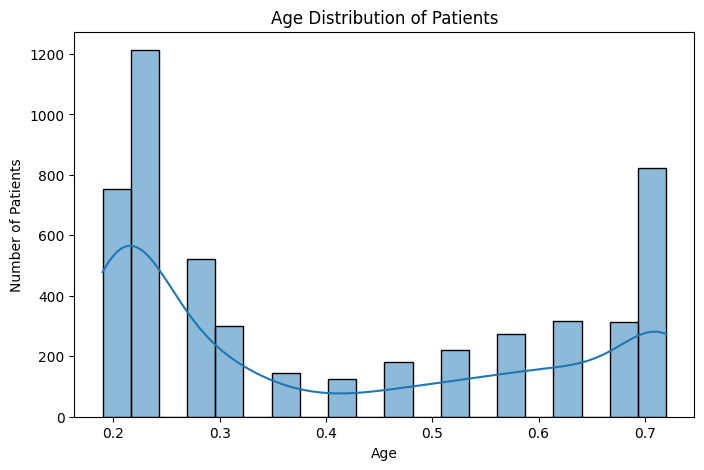

In [23]:
# Age distribution

plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=20, kde=True)

plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

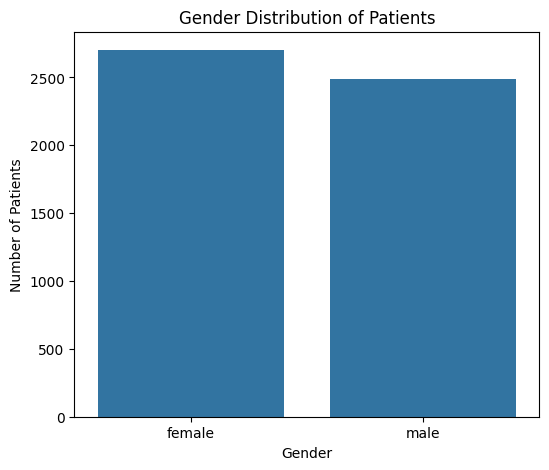

In [24]:
# Gender distribution

plt.figure(figsize=(6,5))

sns.countplot(x='gender', data=df)

plt.title("Gender Distribution of Patients")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.show()

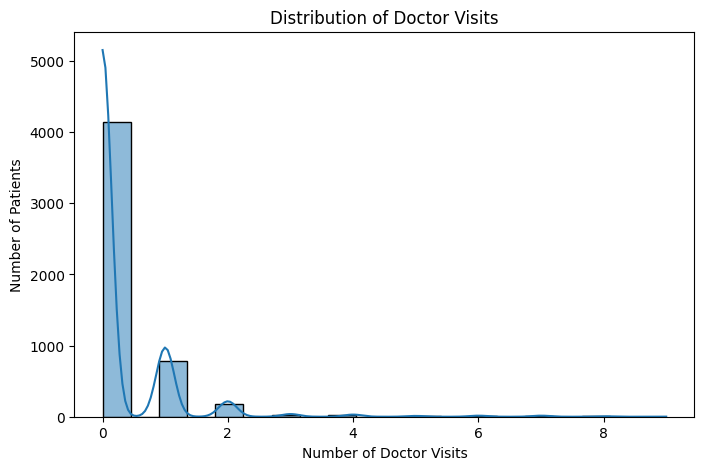

In [27]:
# Doctor visits distribution

plt.figure(figsize=(8,5))

sns.histplot(df['visits'], bins=20, kde=True)

plt.title("Distribution of Doctor Visits")
plt.xlabel("Number of Doctor Visits")
plt.ylabel("Number of Patients")

plt.show()

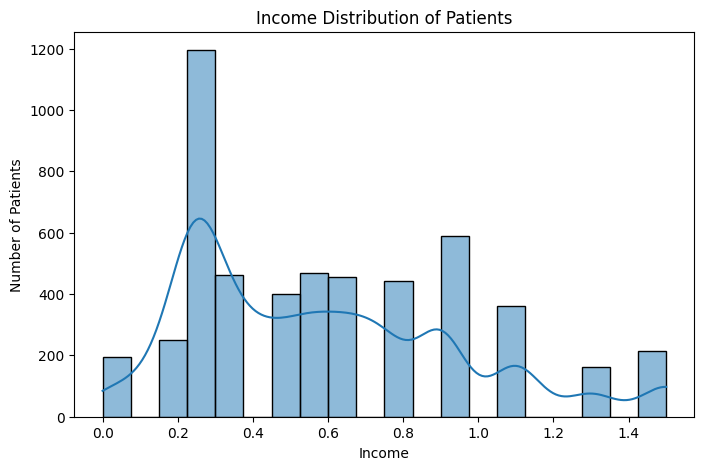

In [28]:
# income distribution

plt.figure(figsize=(8,5))

sns.histplot(df['income'], bins=20, kde=True)

plt.title("Income Distribution of Patients")
plt.xlabel("Income")
plt.ylabel("Number of Patients")

plt.show()


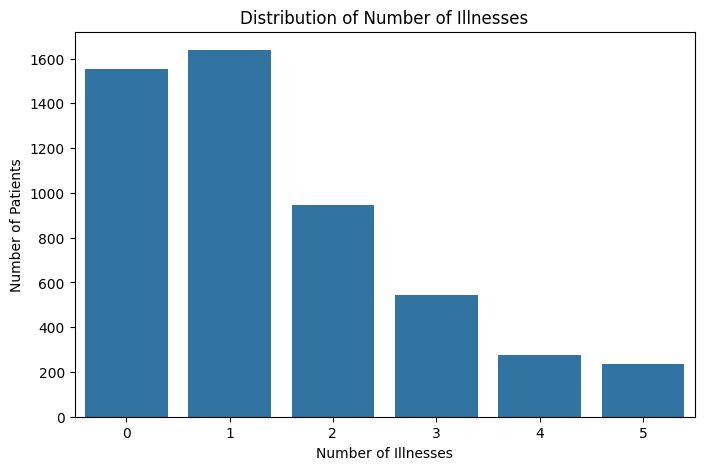

In [29]:
# illness distribution
plt.figure(figsize=(8,5))

sns.countplot(x='illness', data=df)

plt.title("Distribution of Number of Illnesses")
plt.xlabel("Number of Illnesses")
plt.ylabel("Number of Patients")

plt.show()

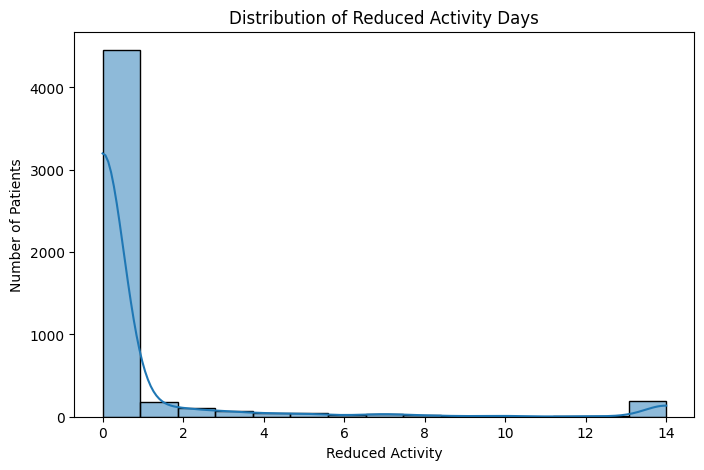

In [33]:
# reduce activity distribution
plt.figure(figsize=(8,5))

sns.histplot(df['reduced'], bins=15, kde=True)

plt.title("Distribution of Reduced Activity Days")
plt.xlabel("Reduced Activity")
plt.ylabel("Number of Patients")

plt.show()

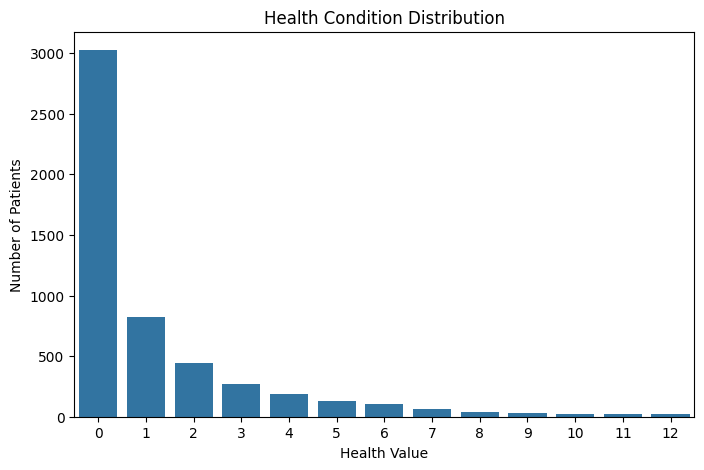

In [34]:
# health distribution
plt.figure(figsize=(8,5))

sns.countplot(x='health', data=df)

plt.title("Health Condition Distribution")
plt.xlabel("Health Value")
plt.ylabel("Number of Patients")

plt.show()

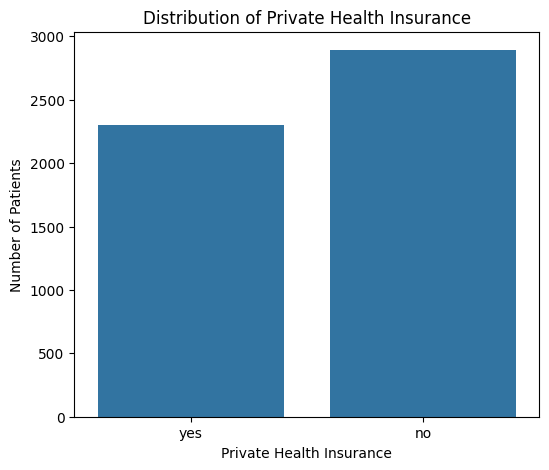

In [35]:
# private health insurance

plt.figure(figsize=(6,5))
sns.countplot(x='private', data=df)
plt.title("Distribution of Private Health Insurance")
plt.xlabel("Private Health Insurance")
plt.ylabel("Number of Patients")

plt.show()

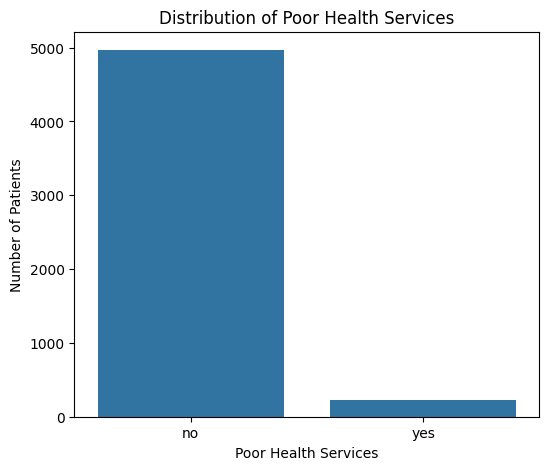

In [36]:
# free poor health service
plt.figure(figsize=(6,5))
sns.countplot(x='freepoor', data=df)
plt.title("Distribution of Poor Health Services")
plt.xlabel("Poor Health Services")
plt.ylabel("Number of Patients")

plt.show()

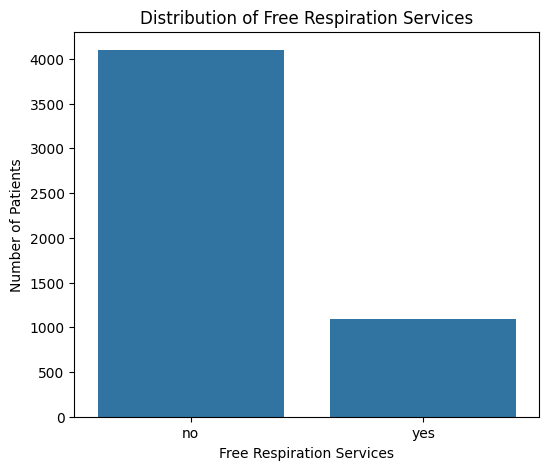

In [37]:
# free respiration service
plt.figure(figsize=(6,5))
sns.countplot(x='freerepat', data=df)
plt.title("Distribution of Free Respiration Services")
plt.xlabel("Free Respiration Services")
plt.ylabel("Number of Patients")

plt.show()

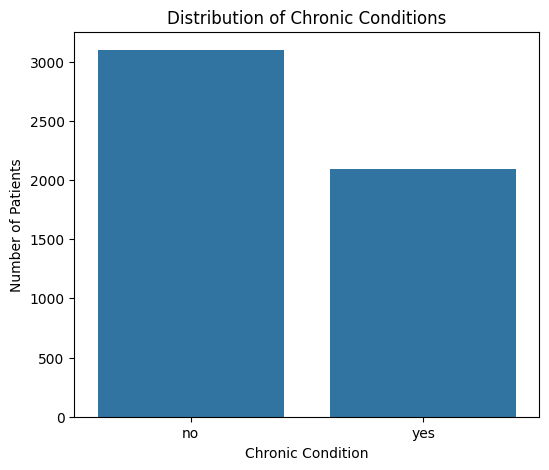

In [39]:
# chronic diseases distribution
plt.figure(figsize=(6,5))
sns.countplot(x='nchronic', data=df)
plt.title("Distribution of Chronic Conditions")
plt.xlabel("Chronic Condition")
plt.ylabel("Number of Patients")

plt.show()

# Univariate Analysis insights
- Most patients have low doctor visits, and many patients have no doctor visits.

- The number of female patients is slightly higher than male patients.

- Most patients have no illness or only one illness.

- A large number of patients have no reduced activity due to health problems.

- Chronic diseases are present in a considerable number of patients.

- A significant number of patients do not have private health insurance.

Overall, the dataset represents patients with different health conditions, age groups, income levels, and healthcare needs.

## Multivariate Analysis

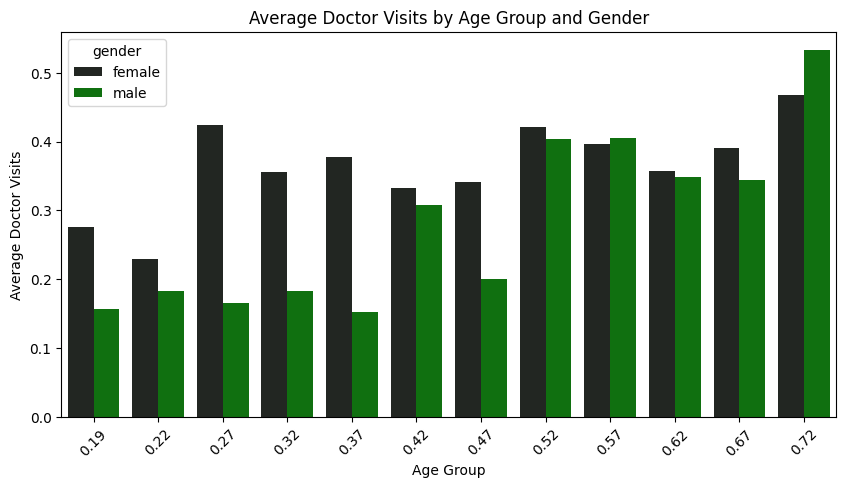

In [43]:
# Age , Gender and Doctor Visists
plt.figure(figsize=(10,5))

sns.barplot(
    x='age',
    y='visits',
    hue='gender',
    data=df,
    errorbar=None,
    palette='dark:green'
)

plt.title("Average Doctor Visits by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel("Average Doctor Visits")

plt.xticks(rotation=45)

plt.show()



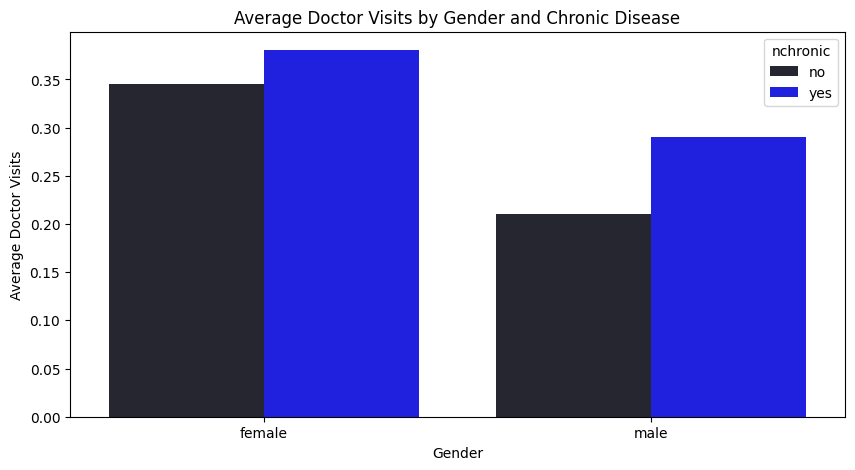

In [44]:
 #Gender + Chronic Disease + Doctor Visits
plt.figure(figsize=(10,5))
sns.barplot(
     x='gender',
     y='visits',
     hue='nchronic',
     data=df,
     errorbar=None,
     palette='dark:blue'
 )

plt.title("Average Doctor Visits by Gender and Chronic Disease")
plt.xlabel("Gender")
plt.ylabel("Average Doctor Visits")

plt.show()

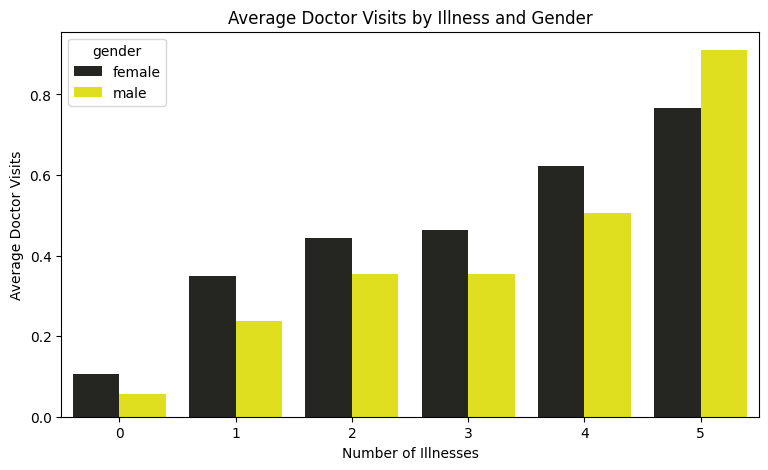

In [45]:
# Illness + Gender + doctor visits
plt.figure(figsize=(9,5))

sns.barplot(
    x='illness',
    y='visits',
    hue='gender',
    data=df,
    errorbar=None,
    palette='dark:yellow'
)

plt.title("Average Doctor Visits by Illness and Gender")
plt.xlabel("Number of Illnesses")
plt.ylabel("Average Doctor Visits")

plt.show()

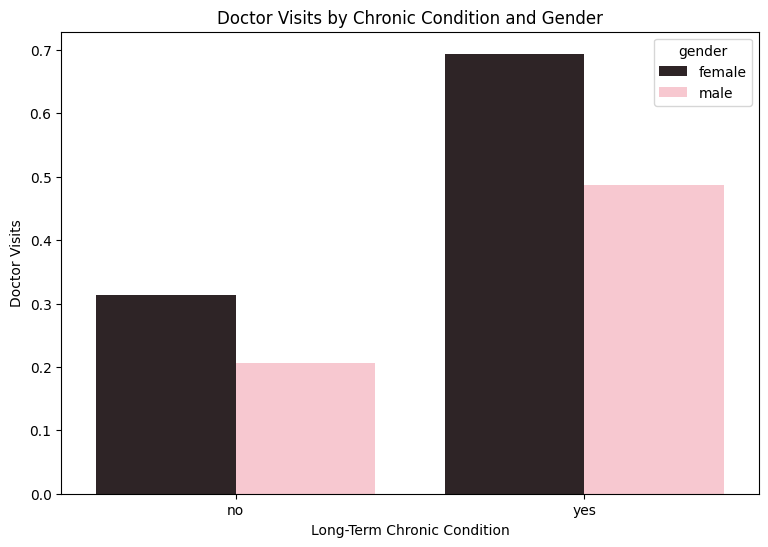

In [47]:
# Chronic Condition + Gender + Visits
plt.figure(figsize=(9,6))

sns.barplot(
    data=df,
    x='lchronic',
    y='visits',
    hue='gender',
    errorbar=None,
    palette='dark:pink'
)

plt.title("Doctor Visits by Chronic Condition and Gender")
plt.xlabel("Long-Term Chronic Condition")
plt.ylabel("Doctor Visits")

plt.show()

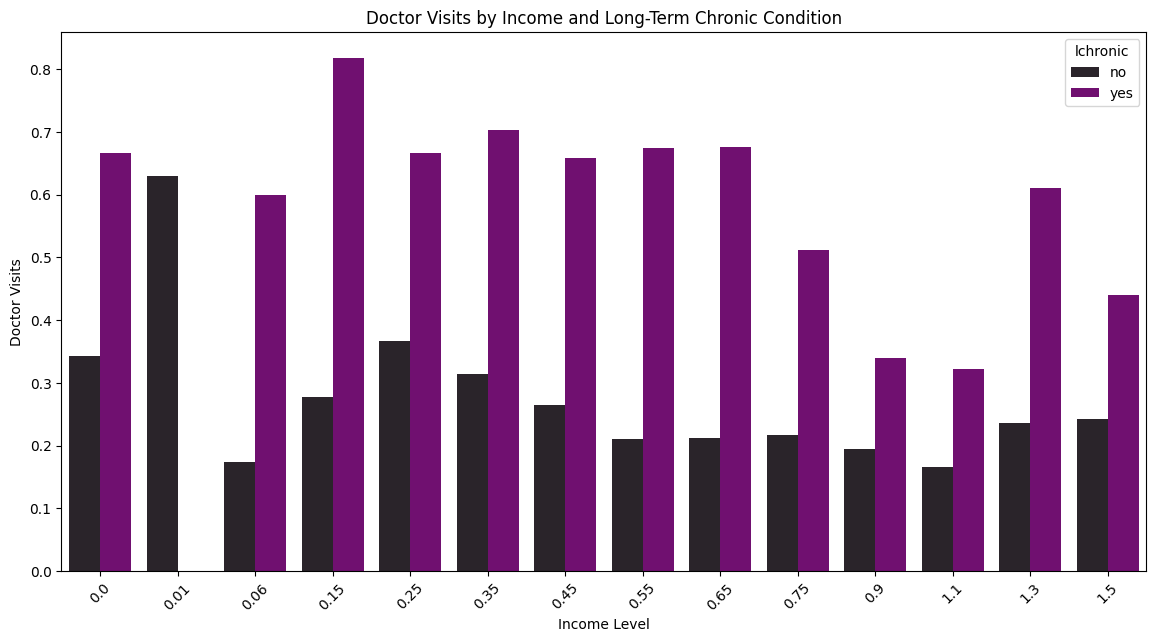

In [48]:
# Income + Chronic Condition + Visits
plt.figure(figsize=(14,7))

sns.barplot(
    data=df,
    x='income',
    y='visits',
    hue='lchronic',
    errorbar=None,
    palette='dark:purple'
)

plt.title("Doctor Visits by Income and Long-Term Chronic Condition")

plt.xlabel("Income Level")
plt.ylabel("Doctor Visits")

plt.xticks(rotation=45)

plt.show()

## Correlation Analysis


Correlation measures the strength and direction of a linear relationship between numerical variables.

In [49]:
# Numerical Correlation Matrix
numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

correlation_matrix

,visits,age,income,illness,reduced,health
visits,1.000000,0.124537,-0.076840,0.223552,0.418954,0.193272
age,0.124537,1.000000,-0.271073,0.204984,0.094745,0.018616
income,-0.076840,-0.271073,1.000000,-0.148812,-0.047545,-0.085790
illness,0.223552,0.204984,-0.148812,1.000000,0.218116,0.360110
reduced,0.418954,0.094745,-0.047545,0.218116,1.000000,0.280208
health,0.193272,0.018616,-0.085790,0.360110,0.280208,1.000000


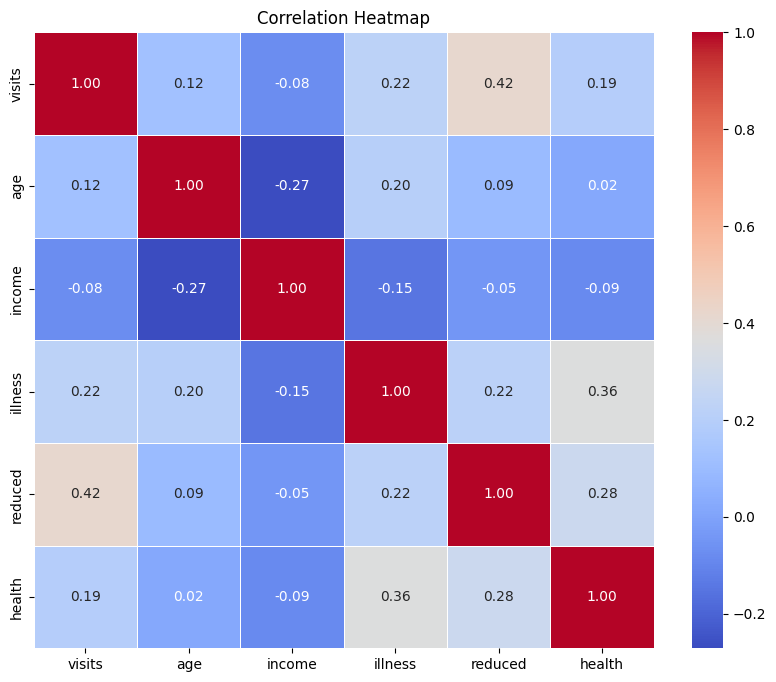

In [50]:
# Correlation Heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

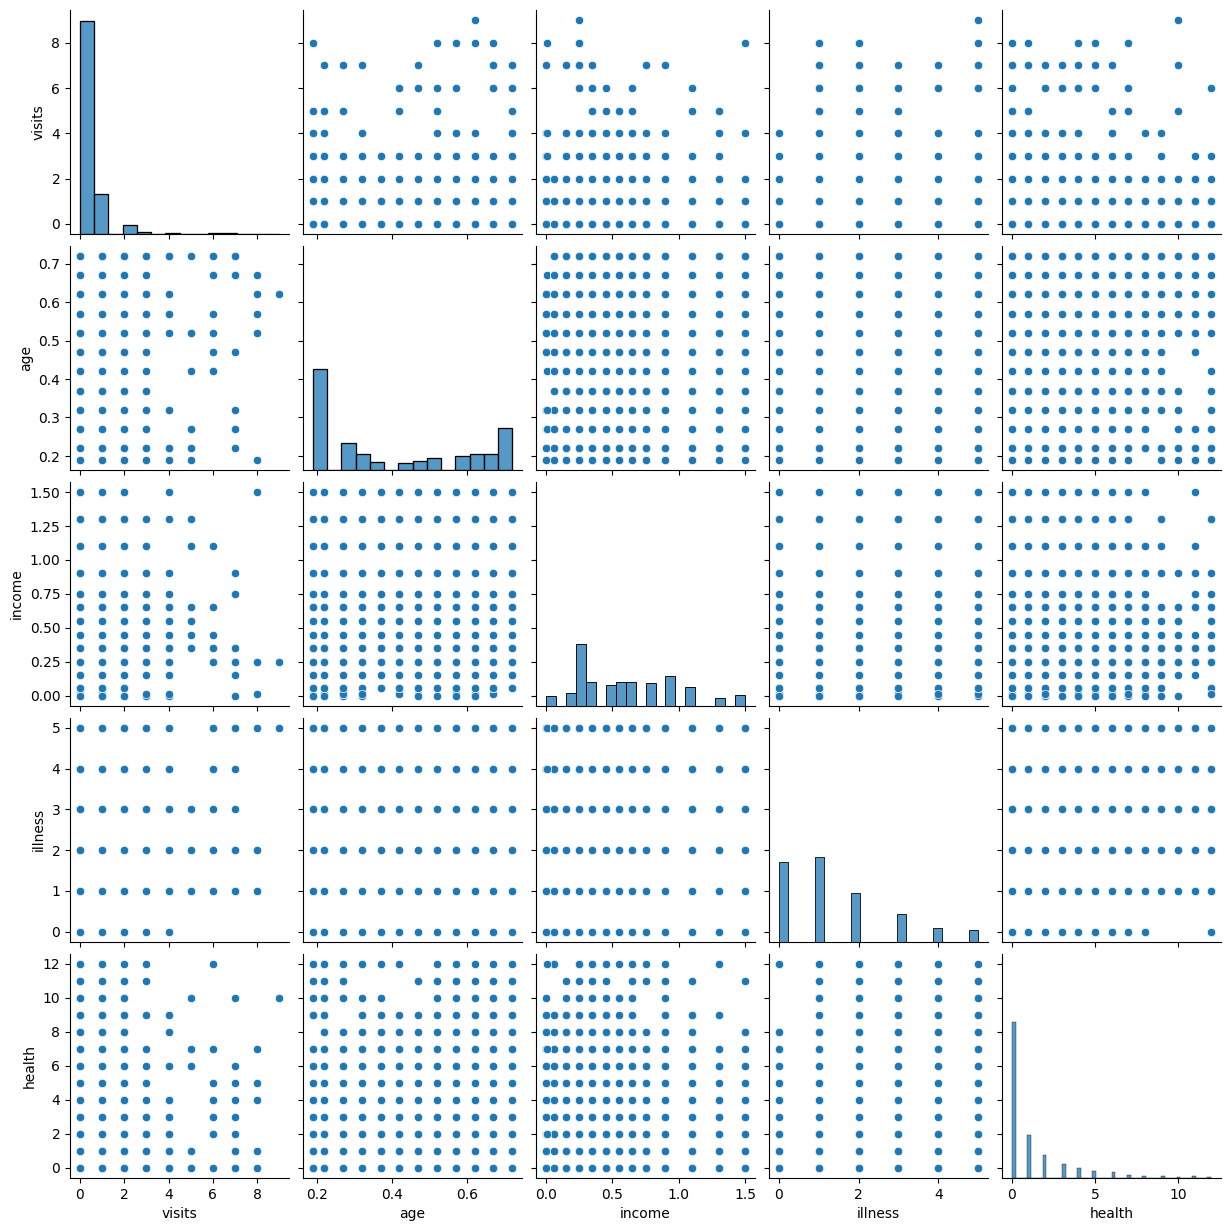

In [52]:
# pair plot
sns.pairplot(
    df[['visits', 'age', 'income', 'illness', 'health']]
)

plt.show()


In [53]:
# Final KPI summary
print("Total Patients:", len(df))
print("Average Doctor Visits:", round(df['visits'].mean(), 2))
print("Maximum Doctor Visits:", df['visits'].max())
print("Minimum Doctor Visits:", df['visits'].min())

Total Patients: 5190
Average Doctor Visits: 0.3
Maximum Doctor Visits: 9
Minimum Doctor Visits: 0


## Important Insights
- Doctor visits vary across different illness levels, indicating differences in healthcare utilization among patients.

- Age groups show different patterns in doctor visits, suggesting that healthcare needs vary with age.

- Doctor visit patterns also differ between male and female patients.

- Patients with chronic health conditions tend to show different doctor-visit patterns compared with patients without such conditions.


- Income level shows differences in healthcare utilization patterns.
Insurance status also provides useful information about doctor-visit behavior.

- Multivariate analysis shows that considering multiple patient characteristics together gives a better understanding of healthcare utilization than analyzing a single factor alone.

- Correlation analysis helps identify relationships among numerical variables, while pair plots and distribution plots help visualize these patterns.

Overall, the analysis highlights that patient health conditions and demographic factors are associated with differences in doctor visits.